In [58]:
# IMPORT LIBRAIES

In [59]:
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd

In [60]:
# CONNECT DATABASE

In [61]:
conn = sqlite3.connect('ipl_data.db')
print("Database connected successfully")

Database connected successfully


In [62]:
# RUN OVERALL WIN% QUERY FROM PYTHON

In [63]:
query = """
SELECT COUNT(*) AS total_matches,
       COUNT(CASE WHEN winner LIKE 'Royal Challengers%' THEN 1 END) AS wins,
       ROUND(COUNT(CASE WHEN winner LIKE 'Royal Challengers%' THEN 1 END) * 100.0 / COUNT(*), 1) AS win_pct
FROM matches
WHERE team1 LIKE 'Royal Challengers%' or team2 LIKE 'Royal Challengers%'
"""
overall = pd.read_sql_query(query, conn)
print("Overall RCB record (from SQL):")
print(overall)

Overall RCB record (from SQL):
   total_matches  wins  win_pct
0            255   123     48.2


In [64]:
# SEASON WIN% QUERY + VISUALIZATION

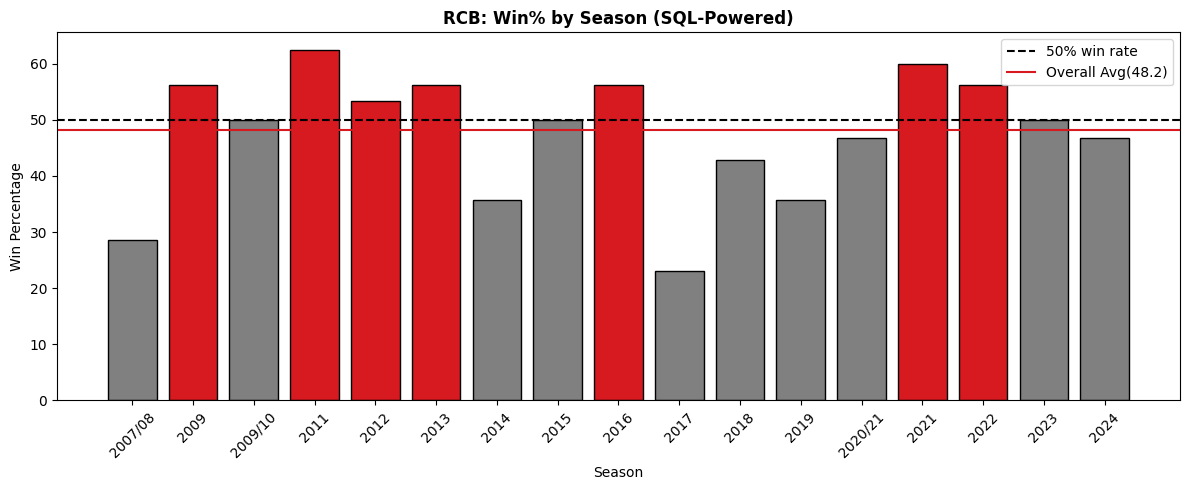

In [65]:
query = """
SELECT season,
       COUNT(*) AS total_matches,
       COUNT(CASE WHEN winner LIKE 'Royal Challengers%' THEN 1 END) AS wins,
       ROUND(COUNT(CASE WHEN winner LIKE 'Royal Challengers%' THEN 1 END) * 100.0 / COUNT(*), 1) AS win_pct
FROM matches
WHERE team1 LIKE 'Royal Challengers%' or team2 LIKE 'Royal Challengers%'
GROUP BY season
ORDER BY season
"""
season_data = pd.read_sql_query(query, conn)
colors = ['#D71920' if pct > 50 else '#808080' for pct in season_data['win_pct']]
plt.figure(figsize=(12,5))

plt.bar(season_data['season'].astype('str') ,season_data['win_pct'], color = colors,edgecolor = 'black')
plt.axhline(y=50, linestyle = '--', color = 'black', label = '50% win rate')
plt.axhline(y=48.2, linestyle = '-', color = '#D71920', label = 'Overall Avg(48.2)')
plt.xlabel('Season')
plt.ylabel('Win Percentage')
plt.title('RCB: Win% by Season (SQL-Powered)', fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('rcb_season_winpct_sql.png',dpi=150,bbox_inches = 'tight')
plt.show()

In [66]:
import os
os.chdir('H:/sql_project/')
print(os.getcwd())

H:\sql_project


In [67]:
# TOSS ANALYSIS QUERY + VISUALIZATION

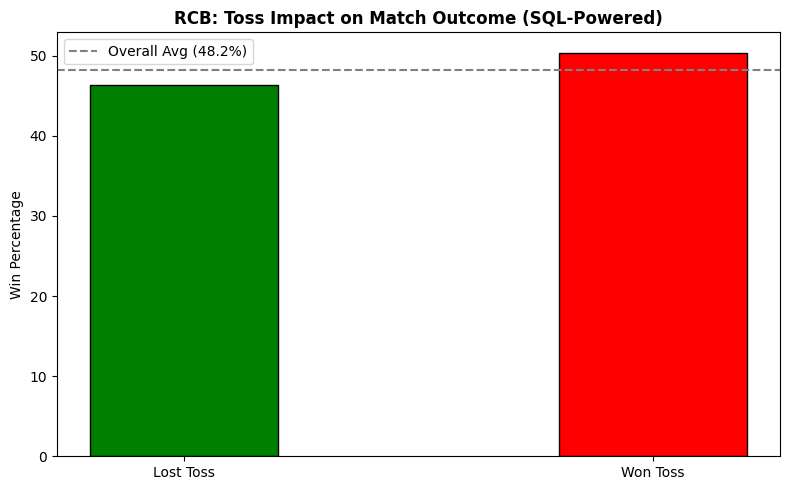

In [68]:
query = """
SELECT 
    CASE 
        WHEN toss_winner LIKE 'Royal Challengers%' THEN 'Won Toss'
        ELSE 'Lost Toss'
    END AS toss_result,
    COUNT(*) AS total_matches,
    COUNT(CASE WHEN winner LIKE 'Royal Challengers%' THEN 1 END) AS wins,
    ROUND(COUNT(CASE WHEN winner LIKE 'Royal Challengers%' THEN 1 END) * 100.0 / COUNT(*), 1) AS win_pct
FROM matches
WHERE team1 LIKE 'Royal Challengers%'
   OR team2 LIKE 'Royal Challengers%'
GROUP BY toss_result
"""

toss_data = pd.read_sql_query(query, conn)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(toss_data['toss_result'], toss_data['win_pct'], color=['green', 'red'], edgecolor='black', width=0.4)
plt.axhline(y=48.2, linestyle='--', color='gray', label='Overall Avg (48.2%)')
plt.ylabel('Win Percentage')
plt.title('RCB: Toss Impact on Match Outcome (SQL-Powered)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('toss_analysis_sql.png', dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# TOP BATSMEN QUERY + VISUALIZATION

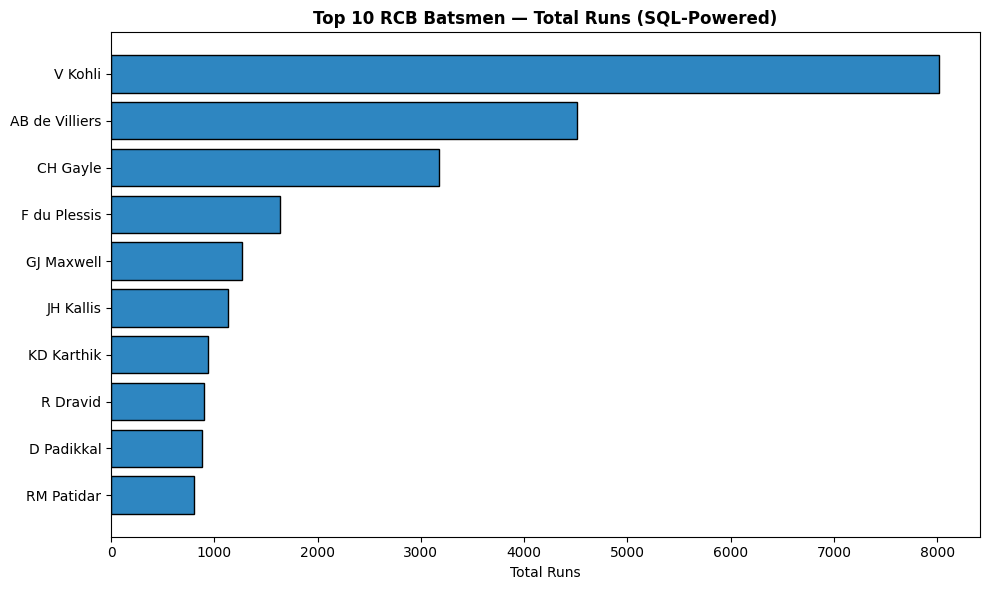

In [70]:
query = """
SELECT 
    d.batter,
    SUM(d.batsman_runs) AS total_runs
FROM deliveries d
JOIN matches m ON d.match_id = m.id
WHERE (m.team1 LIKE 'Royal Challengers%'
    OR m.team2 LIKe 'Royal Challengers%')
  AND d.batting_team LIKE 'Royal Challengers%'
GROUP BY d.batter
ORDER BY total_runs DESC
LIMIT 10
"""

top_batsmen = pd.read_sql_query(query, conn)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_batsmen['batter'][::-1], top_batsmen['total_runs'][::-1], color='#2E86C1', edgecolor='black')
plt.xlabel('Total Runs')
plt.title('Top 10 RCB Batsmen — Total Runs (SQL-Powered)', fontweight='bold')
plt.tight_layout()
plt.savefig('top_batsmen_sql.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
# VERIFY SQL RESULTS MATCH PANDAS EDA

In [72]:
sql_total = overall['total_matches'][0]
sql_wins = overall['wins'][0]
sql_win_pct = overall['win_pct'][0]

# Pandas results from Day 1 EDA
pandas_total = 255
pandas_wins = 123
pandas_win_pct = 48.2

# Compare
print("=== SQL vs Pandas Verification ===")
print(f"Total Matches — SQL: {sql_total}, Pandas: {pandas_total} → {'✅ Match!' if sql_total == pandas_total else '❌ Mismatch!'}")
print(f"Wins — SQL: {sql_wins}, Pandas: {pandas_wins} → {'✅ Match!' if sql_wins == pandas_wins else '❌ Mismatch!'}")
print(f"Win% — SQL: {sql_win_pct}, Pandas: {pandas_win_pct} → {'✅ Match!' if sql_win_pct == pandas_win_pct else '❌ Mismatch!'}")

=== SQL vs Pandas Verification ===
Total Matches — SQL: 255, Pandas: 255 → ✅ Match!
Wins — SQL: 123, Pandas: 123 → ✅ Match!
Win% — SQL: 48.2, Pandas: 48.2 → ✅ Match!


In [73]:
import os

# Change to your older directory
os.chdir('C:/Users/siris/')  # Replace with your actual old path

# Verify the change
print("Current directory:", os.getcwd())

Current directory: C:\Users\siris


In [74]:
# REUSABLE run_query() FUNCTION

In [75]:
def run_query(query):
    """
    Connect to ipl_data.db, execute a SQL query,
    and return results as a Pandas DataFrame.
    """
    conn = sqlite3.connect('ipl_data.db')
    result = pd.read_sql_query(query, conn)
    conn.close()
    return result

# Test with two different queries
print("=== Testing run_query() ===")

# Test 1: Count matches per season
result1 = run_query("""
    SELECT season, COUNT(*) AS matches
    FROM matches
    GROUP BY season
    ORDER BY season
    LIMIT 3
""")
print("Query 1 — Matches per season (first 3):")
print(result1)

# Test 2: Top 3 venues
result2 = run_query("""
    SELECT venue, COUNT(*) AS matches
    FROM matches
    GROUP BY venue
    ORDER BY matches DESC
    LIMIT 3
""")
print("\nQuery 2 — Top 3 venues:")
print(result2)

=== Testing run_query() ===
Query 1 — Matches per season (first 3):
    season  matches
0  2007/08       58
1     2009       57
2  2009/10       60

Query 2 — Top 3 venues:
                   venue  matches
0           Eden Gardens       77
1       Wankhede Stadium       73
2  M Chinnaswamy Stadium       65


In [76]:
# CLOSE CONNECTION

In [77]:
conn.close()
print("Connection closed.")

Connection closed.


## Day 8 Summary: Python + SQL Integration

 Completed
- Connected to SQLite database from Python using sqlite3
- Ran SQL queries and loaded results into Pandas DataFrames
- Created visualizations from SQL query results using Matplotlib
- Verified SQL results match Pandas EDA results exactly
- Built a reusable run_query() function for cleaner code

 Key Skills Learned
- pd.read_sql_query() for SQL → DataFrame conversion
- Combining SQL aggregation with Python visualization
- Cross-validating results across SQL and Pandas
- Writing modular, reusable database functions

 Verification
✅ Total matches: SQL 255 = Pandas 255
✅ Wins: SQL 123 = Pandas 123
✅ Win%: SQL 48.2% = Pandas 48.2%

 Next
Day 9 — Parameterized Queries: Dynamic SQL with Python variables